In [1]:
# AfyaFlow AI - Patient Demand Forecasting with XGBoost

## Import Required Libraries

In [2]:
# Data manipulation
import pandas as pd
import numpy as np
import pyarrow

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go

# Plot aesthetics
color_pal = sns.color_palette()
plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb  # ML algorithm for forecasting
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Error metrics

## Load the Data

In [3]:
filepath = 'data/skyline_hospital_bill_charge_report.csv'

df = pd.read_csv(filepath)
df

,Open Date,Bill No.,Charge Head,Doctor Code,Qty
0,2020-05-18,BL427653,OP Consultation,DOC0114,1
1,2020-05-18,BL427654,OP Consultation,DOC0114,1
2,2020-05-18,BL427655,OP Consultation,DOC0207,1
3,2020-05-18,BL427656,OP Consultation,DOC0114,1
4,2020-05-18,BL427657,OP Consultation,DOC0114,1
...,...,...,...,...,...
126152,2022-12-31,BL678528,OP Consultation,DOC0553,1
126153,2022-12-31,BL678529,OP Consultation,DOC0207,1
126154,2022-12-31,BL678530,OP Consultation,DOC0114,1
126155,2022-12-31,BL678531,OP Consultation,DOC0114,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126157 entries, 0 to 126156
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Open Date    126157 non-null  object
 1   Bill No.     126157 non-null  object
 2   Charge Head  126157 non-null  object
 3   Doctor Code  126157 non-null  object
 4   Qty          126157 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 4.8+ MB


## Data Cleaning

For time series forecasting, only the dates (`Open Date`) and the count of outpatient consultations (`Qty`) shall be used. Therefore, the 3 remaining columns are to be dropped, which will make this a time series data.

To make the columns more understandable, we can rename `'Open Date'` as `'Date'` and `'Qty'` as `'Patients'`, representing the number of patients for each date.

In [5]:
df = df[['Open Date', 'Qty']]
df = df.rename(columns={'Open Date': 'Date', 'Qty': 'Patients'})
df

,Date,Patients
0,2020-05-18,1
1,2020-05-18,1
2,2020-05-18,1
3,2020-05-18,1
4,2020-05-18,1
...,...,...
126152,2022-12-31,1
126153,2022-12-31,1
126154,2022-12-31,1
126155,2022-12-31,1


We can see that the `'Date'` column is read with an `object` data type. We must change this to the pandas `datetime` format using `to_datetime()`. This will allow us to truly perceive it as time data, and use appropriate `datetime` functions for it.

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date        datetime64[ns]
Patients             int64
dtype: object

Having a closer look at our time series data lets us know that we have duplicated dates, and the **patient arrival counts are not summed up in one date** or instance. This is why we have more observations (rows) than what is expected. An easy fix for this would be to use `groupby()` on the `'Date'` column with the `sum()` method on the `'Patients'` column.

In [7]:
df = df.groupby(by='Date', as_index=False)['Patients'].sum()

In [8]:
df

,Date,Patients
0,2020-05-18,67
1,2020-05-19,75
2,2020-05-20,74
3,2020-05-21,55
4,2020-05-22,62
...,...,...
851,2022-12-27,114
852,2022-12-28,156
853,2022-12-29,105
854,2022-12-30,24


Now we can be sure that **there are no more duplicated dates**.

In [9]:
df[df['Date'].duplicated()]

,Date,Patients


In [10]:
df.dtypes

Date        datetime64[ns]
Patients             int64
dtype: object

Since this seems to be cleaned enough data, we can save the time series data that was once a csv file, into a **parquet file**. This would allow us to **reduce memory consumption**.                                  

In [11]:
df.to_parquet('data/patient_arrivals.parquet')

Let's load and read the data once again.

In [12]:
parquet_file = 'data/patient_arrivals.parquet'
df = pd.read_parquet(parquet_file, engine='pyarrow')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 856 entries, 0 to 855
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      856 non-null    datetime64[ns]
 1   Patients  856 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 13.5 KB


A convention with time series data is to set the `datetime` column into an index.

In [14]:
df = df.set_index('Date')
df

,Patients
Date,
2020-05-18,67
2020-05-19,75
2020-05-20,74
2020-05-21,55
2020-05-22,62
...,...
2022-12-27,114
2022-12-28,156
2022-12-29,105


Now we can see that the duplicated dates issue on the data is fixed, and has significantly **reduced the number of observations from 126,157 to just 856**. But this poses another issue. If we convert 2 years, 7 months, and 14 days into just the number of days, **we should be getting 958 days/rows**. Let's **define the date range for this so that we can have the true number of days from 2020-05-18 to 2022-12-31**.

In [15]:
new_index = pd.date_range(start='2020-05-18', end='2022-12-31', freq='D')
df = df.reindex(new_index)
df.index.name = 'Date'
df

,Patients
Date,
2020-05-18,67.0
2020-05-19,75.0
2020-05-20,74.0
2020-05-21,55.0
2020-05-22,62.0
...,...
2022-12-27,114.0
2022-12-28,156.0
2022-12-29,105.0


## Visualize the Data

In [16]:
fig = go.Figure()

# Add scatter trace for patients
fig.add_trace(go.Scatter(x=df.index, y=df['Patients'], 
                          mode='lines', 
                          name='Number of Patients'))

# Add markers for missing values
missing_dates = df[df['Patients'].isna()].index
missing_values_trace = go.Scatter(x=missing_dates, y=[df['Patients'].min()]*len(missing_dates),
                                  mode='markers', marker=dict(color='red', symbol='x'),
                                  name='Missing Values')
fig.add_trace(missing_values_trace)

# Set plot title and axis labels
fig.update_layout(title='Daily Patient Arrivals (with Missing Values',
                  xaxis_title='Date', yaxis_title='Patient Count')

# Show plot
fig.show()

In [17]:
missing_vals = df[df['Patients'].isna()]
missing_vals

,Patients
Date,
2020-05-24,NaN
2020-05-31,NaN
2020-06-07,NaN
2020-06-14,NaN
2020-06-21,NaN
...,...
2022-09-18,NaN
2022-09-25,NaN
2022-10-02,NaN


We can see **102 missing instances** of patient arrival counts. To see the pattern of missing values, we can add a time series feature to identify which days of the week are the missing values coming from.

In [18]:
df = df.copy()
df['date'] = df.index
df['day_of_week'] = df['date'].dt.dayofweek
df.head()

,Patients,date,day_of_week
Date,,,
2020-05-18,67.0,2020-05-18,0
2020-05-19,75.0,2020-05-19,1
2020-05-20,74.0,2020-05-20,2
2020-05-21,55.0,2020-05-21,3
2020-05-22,62.0,2020-05-22,4


The week numbers in the `'day_of_week'` here could be perceived as:

- `0` : `Monday`
- `1` : `Tuesday`
- `2` : `Wednesday`
- `3` : `Thursday`
- `4` : `Friday`
- `5` : `Saturday`
- `6` : `Sunday`


In [19]:
patient_counts_by_week = df.groupby('day_of_week')[['Patients']].sum()
patient_counts_by_week

,Patients
day_of_week,
0,22662.0
1,20406.0
2,21163.0
3,14423.0
4,21794.0
5,25108.0
6,601.0


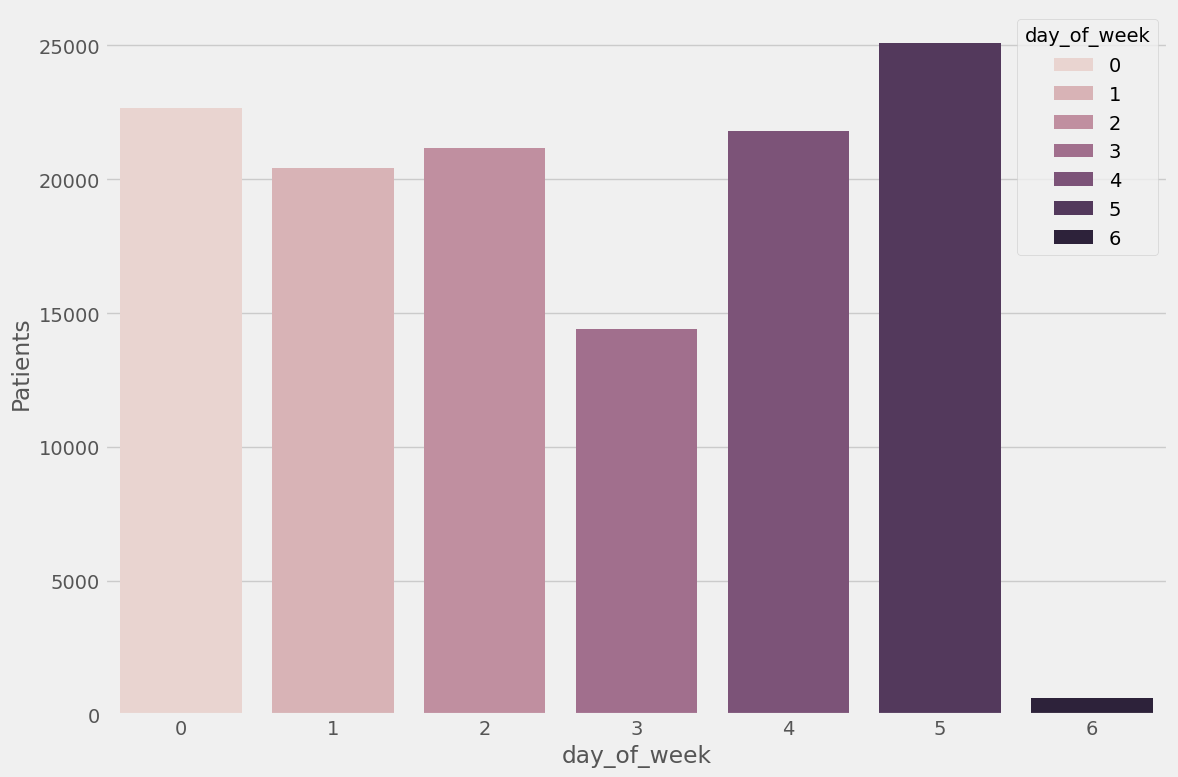

In [20]:
plt.figure(figsize=(12, 8))

sns.barplot(data=patient_counts_by_week, x='day_of_week', y='Patients', hue='day_of_week')

plt.tight_layout()
plt.show()

**Saturday** seems to be the day of the week with the **highest patient arrival counts**. Consequently, **Sunday** seems to be the one with the **lowest patient arrival counts**. What could this possibly mean?

In [21]:
df = df.interpolate(method='linear')

In [22]:
fig = go.Figure()

# Add scatter trace for patients
fig.add_trace(go.Scatter(x=df.index, y=df['Patients'], 
                          mode='lines', 
                          name='Number of Patients'))

# Add markers for missing values
missing_dates = df[df['Patients'].isna()].index
missing_values_trace = go.Scatter(x=missing_dates, y=[df['Patients'].min()]*len(missing_dates),
                                  mode='markers', marker=dict(color='red', symbol='x'),
                                  name='Missing Values')
fig.add_trace(missing_values_trace)

# Set plot title and axis labels
fig.update_layout(title='Daily Patient Arrivals',
                  xaxis_title='Date', yaxis_title='Patient Count')

# Show plot
fig.show()

Now we have eliminated the issue of missing values. Let's proceed to **decompose** our time series data.

## Time Series Decomposition

We can try to decompose the time series data to know its **trend, seasonality, and residual** components.

In [23]:
from statsmodels.tsa.seasonal import STL

In [24]:
patients_series = df['Patients']

In [25]:
# Perform STL decomposition
stl = STL(patients_series, seasonal=7)
result = stl.fit()

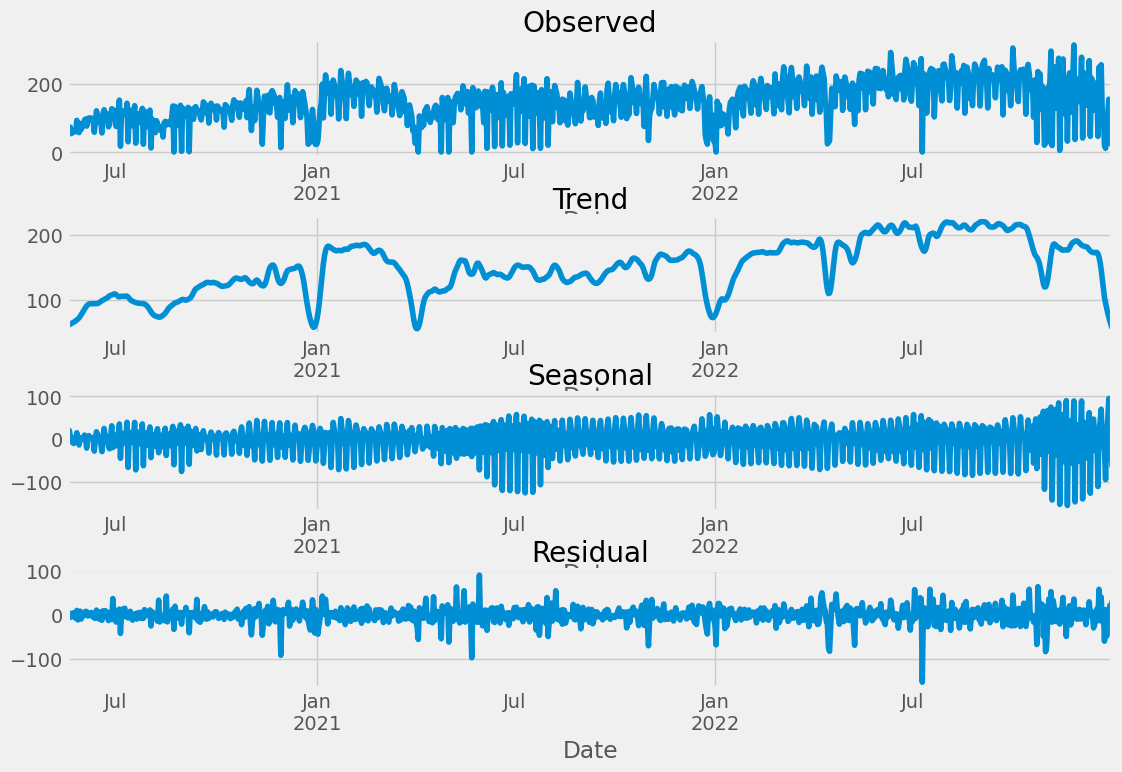

In [26]:
# Plot the components
fig, axes = plt.subplots(4, 1, figsize=(12, 8))
plt.subplots_adjust(hspace=0.5)
result.observed.plot(ax=axes[0], legend=False)
axes[0].set_title('Observed')
result.trend.plot(ax=axes[1], legend=False)
axes[1].set_title('Trend')
result.seasonal.plot(ax=axes[2], legend=False)
axes[2].set_title('Seasonal')
result.resid.plot(ax=axes[3], legend=False)
axes[3].set_title('Residual')

plt.show()

We can see from the time series decomposition that it has no uptrend, it has some seasonality, and a fairly strong residual component. Now we proceed to detect and handle outlier values.

## Outlier Analysis, Detection and Handling

For handling outliers, I have chosen to apply **winsorizetion**, wherein the patient arrival counts that are above the set upper bound, and below the set lower bound will be adjusted to stay within the bounds.

In [27]:
## Calculate the IQR and bounds
Q1 = patients_series.quantile(0.25)
Q3 = patients_series.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 0.1 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')

Lower Bound: 106.2
Upper Bound: 309.0


The lower bound is set to 106.2, while the upper bound is set to 309. This means that any patient arrival counts that are less than 106.2 or greater than 309 are adjusted to have these values.

We can also see that a greater weight was assigned to the Upper bound. This is due to my assumption that there is a greater need to be informed at times when patient arrival counts will be at their peaks, as opposed to times when the patient arrival counts would be at their lowest counts.

In [28]:
def custom_winsorize(x):
    if x < lower_bound:
        return lower_bound
    elif x > upper_bound:
        return upper_bound
    else:
        return x

cleaned_series = patients_series.copy()
cleaned_series = cleaned_series.apply(custom_winsorize)
df['Patients'] = cleaned_series.copy()

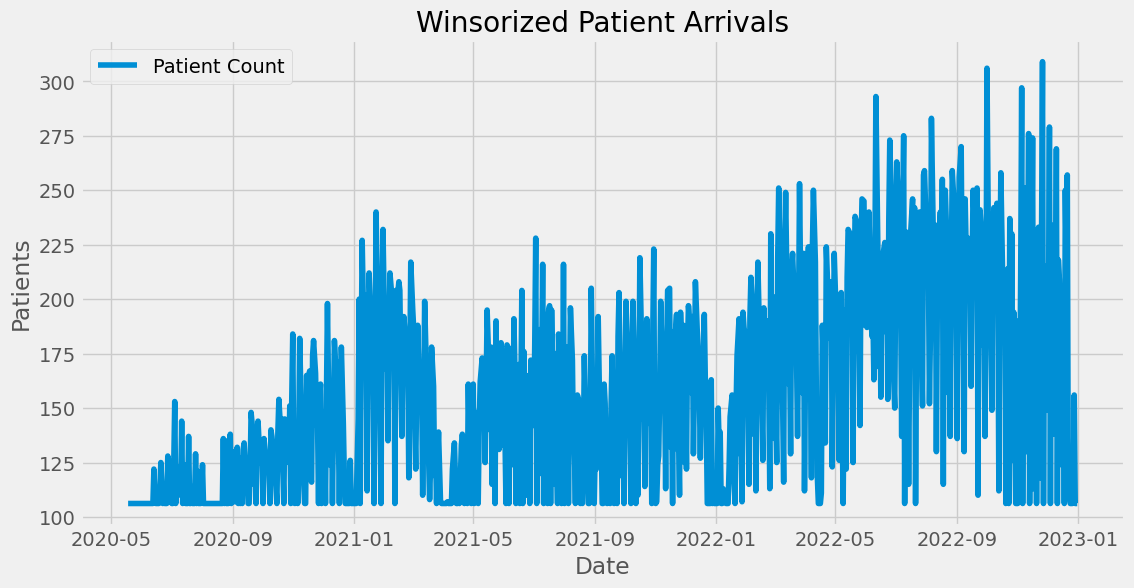

In [29]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the winsorized patient arrivals data
ax.plot(df.index, df['Patients'], label='Patient Count')

# Set the title and labels for the plot
ax.set_title('Winsorized Patient Arrivals')
ax.set_xlabel('Date')
ax.set_ylabel('Patients')

# Show the legend
ax.legend()

# Display the plot
plt.show()

Now we have our winsorized time series data. In order to have a better chance of improving our forecating model, let's proceed to **Feature Engineering**.

## Feature Engineering

**Feature Engineering** is a way to enrich the data. It essentially means that we will do a series of additional calculations with the goal of improving model performance, and to find out which features are the most effective in giving out predictions.

Since we have time series data here, we generate time series features and add rolling statistics as well.

In [30]:
def create_features(df, label=None):
    """
    Create time series features from the datetime index.

    The rolling window is shifted by one day, so the features attached to a
    given date are built only from STRICTLY EARLIER dates. This matters twice:

    1. Without the shift the 7-day window ends on the date being predicted, so
       the feature contains the target itself. That is target leakage - the
       model is rewarded for reading the answer off the feature, and the
       cross-validated error is optimistic.
    2. A future forecast cannot be produced at all from a feature that needs the
       unknown value, so recursive multi-step forecasting is impossible while
       the shift is missing.

    The calendar features, and the lag features built in `add_lags`, were
    already past-only and are unchanged.
    """
    df = df.copy()
    df['date'] = df.index
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['day_of_year'] = df['date'].dt.dayofyear
    
    window_size = 7  # 7-day rolling window
    
    # Shift one day so the window always ends on the previous day
    past = df['Patients'].shift(1)
    
    # Rolling sum
    df['rolling_sum'] = past.rolling(window=window_size).sum()

    # Rolling mean
    df['rolling_mean'] = past.rolling(window=window_size).mean()

    # Rolling median
    df['rolling_median'] = past.rolling(window=window_size).median()

    # Rolling standard deviation
    df['rolling_std'] = past.rolling(window=window_size).std()

    # Rolling quantile (25th percentile)
    quantile_25 = 0.25
    df['rolling_quantile_25'] = past.rolling(window=window_size).quantile(quantile_25)

    # Rolling quantile (75th percentile)
    quantile_75 = 0.75
    df['rolling_quantile_75'] = past.rolling(window=window_size).quantile(quantile_75)

    return df

df = create_features(df)

In [31]:
df.dtypes

Patients                      float64
date                   datetime64[ns]
day_of_week                     int32
month                           int32
day_of_year                     int32
rolling_sum                   float64
rolling_mean                  float64
rolling_median                float64
rolling_std                   float64
rolling_quantile_25           float64
rolling_quantile_75           float64
dtype: object

In [32]:
df.head()

,Patients,date,day_of_week,month,day_of_year,rolling_sum,rolling_mean,rolling_median,rolling_std,rolling_quantile_25,rolling_quantile_75
Date,,,,,,,,,,,
2020-05-18,106.2,2020-05-18,0,5,139,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-19,106.2,2020-05-19,1,5,140,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-20,106.2,2020-05-20,2,5,141,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-21,106.2,2020-05-21,3,5,142,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-22,106.2,2020-05-22,4,5,143,NaN,NaN,NaN,NaN,NaN,NaN


Now that we have generated time series features, let's first have a look on how cross-validation works with time series.

## Time Series Cross-Validation

We use a **Sliding Window Cross-Validation** technique here wherein we ensure that none of the information about the future is fed into model while training, and we give the model observations about something that it shouldn't have seen at that moment in time. We test the model right after a training period finishes.

In [33]:
from sklearn.model_selection import TimeSeriesSplit

In [34]:
tss = TimeSeriesSplit(n_splits=8, test_size=119, gap=1)
df = df.sort_index()

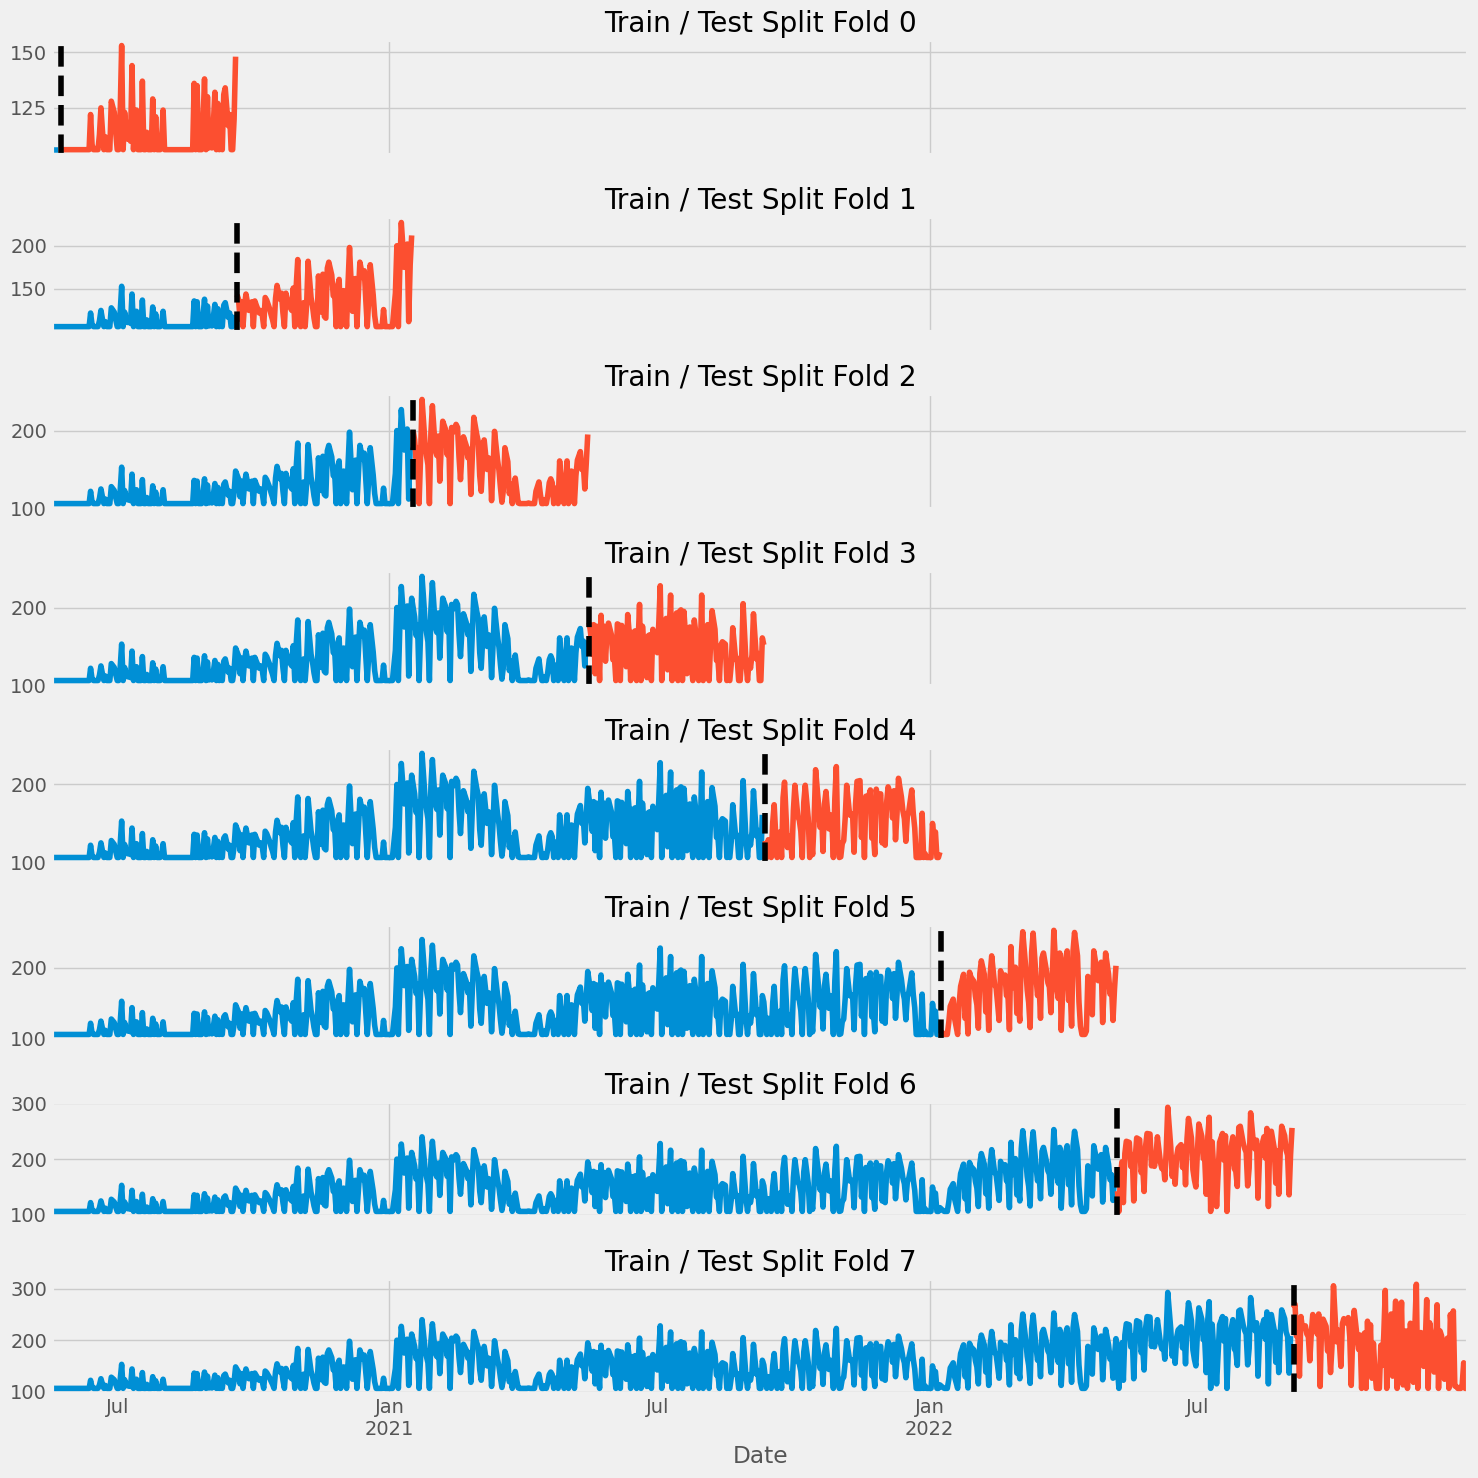

In [35]:
fig, axs = plt.subplots(8, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_index, val_index in tss.split(df):
    train = df.iloc[train_index]
    test = df.iloc[val_index]
    train['Patients'].plot(ax=axs[fold],
                           label='Training Set',
                           title=f'Train / Test Split Fold {fold}')
    test['Patients'].plot(ax=axs[fold], label='Test Set')
    
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1

plt.tight_layout()
plt.show()

In this case, we choose an **8-fold Sliding Window Cross-Validation** technique for our time series data.

## Forecasting horizon

### Lag features

Adding lag features for time series forecasting models is essential, especially for models that aren't specialized for dealing with time series data. They are used to help the forecasting model learn about the temporal structure and historical values.

In [36]:
def add_lags(df):
    target_map = df['Patients'].to_dict()
    df['lag_7_days'] = (df.index - pd.Timedelta('7 days')).map(target_map)
    df['lag_14_days'] = (df.index - pd.Timedelta('14 days')).map(target_map)
    df['lag_21_days'] = (df.index - pd.Timedelta('21 days')).map(target_map)
    df['lag_28_days'] = (df.index - pd.Timedelta('28 days')).map(target_map)
    df['lag_30_days'] = (df.index - pd.Timedelta('30 days')).map(target_map)
    df['lag_60_days'] = (df.index - pd.Timedelta('60 days')).map(target_map)
    df['lag_180_days'] = (df.index - pd.Timedelta('180 days')).map(target_map)
    return df

df = add_lags(df)

In [37]:
df.head()

,Patients,date,day_of_week,month,day_of_year,rolling_sum,rolling_mean,rolling_median,rolling_std,rolling_quantile_25,rolling_quantile_75,lag_7_days,lag_14_days,lag_21_days,lag_28_days,lag_30_days,lag_60_days,lag_180_days
Date,,,,,,,,,,,,,,,,,,
2020-05-18,106.2,2020-05-18,0,5,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-19,106.2,2020-05-19,1,5,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-20,106.2,2020-05-20,2,5,141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-21,106.2,2020-05-21,3,5,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-22,106.2,2020-05-22,4,5,143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
df.dtypes

Patients                      float64
date                   datetime64[ns]
day_of_week                     int32
month                           int32
day_of_year                     int32
rolling_sum                   float64
rolling_mean                  float64
rolling_median                float64
rolling_std                   float64
rolling_quantile_25           float64
rolling_quantile_75           float64
lag_7_days                    float64
lag_14_days                   float64
lag_21_days                   float64
lag_28_days                   float64
lag_30_days                   float64
lag_60_days                   float64
lag_180_days                  float64
dtype: object

## Model Building

Now that we have finished feature engineering and added time lags, it is now time to build the forecasting model. The forecasting model we're about to use is known as **eXtreme Gradient Boosting** (XGBoost).

XGBoost is a powerful machine learning algorithm that is widely used for various predictive modeling tasks, including time series forecasting.
Here's how it works:

- **Boosting Superpower**: XGBoost is like having a team of very smart experts. Each expert (or "weak learner") tries to understand the patterns in your data. They start by making a guess, and they might not be very good at it initially.
    
- **Learning from Mistakes**: XGBoost doesn't give up easily. It looks at where each expert made mistakes and focuses more on the areas where they need improvement. This way, they learn from their mistakes and get better with each try.
    
- **Combining Expert Opinions**: After multiple rounds of learning and improving, XGBoost combines the opinions of all the experts to make a final prediction. It's like getting advice from a group of specialists who have become really good at understanding your data.
    
- **Making Accurate Predictions**: The combined prediction is usually very accurate because it's based on the collective wisdom of the experts who have learned from their mistakes. This helps you forecast future values in your time series data with high precision.
    

So, why is XGBoost great for time series forecasting?

- **Handles Complex Patterns**: Time series data often has intricate patterns, like seasonal trends or irregular fluctuations. XGBoost excels at capturing these patterns, even when they're not straightforward.
    
- **Robust to Noise**: In real-world data, there can be noise or randomness that makes predictions challenging. XGBoost is robust and can filter out the noise to focus on the important signals.
    
- **Flexibility**: It's flexible and can be used for various types of time series data, whether you're predicting sales, energy consumption, or anything else that changes over time.
    
- **Automatic Feature Engineering**: XGBoost can automatically find the most important features or factors affecting your predictions, saving you a lot of manual work.
    

In a nutshell, XGBoost is your reliable partner for time series forecasting. It's like having a team of experts who learn from their mistakes and work together to make highly accurate predictions from your historical data. It's a valuable tool for making informed decisions and planning for the future.


## Train Using Time Series Cross-Validation

Before training our model, we first define the metrics we will use to measure model performance.

In [39]:
# Define the error metrics

def root_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred)**2))

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100

In [40]:
df.columns

Index(['Patients', 'date', 'day_of_week', 'month', 'day_of_year',
       'rolling_sum', 'rolling_mean', 'rolling_median', 'rolling_std',
       'rolling_quantile_25', 'rolling_quantile_75', 'lag_7_days',
       'lag_14_days', 'lag_21_days', 'lag_28_days', 'lag_30_days',
       'lag_60_days', 'lag_180_days'],
      dtype='object')

In [41]:
from sklearn.model_selection import TimeSeriesSplit
tss = TimeSeriesSplit(n_splits=8, test_size=119, gap=1)
df = df.sort_index()

# The features are now built only from strictly past values, so they are
# computed once on the full frame (cells 54 and 67) and then sliced, instead of
# being recomputed per fold. Recomputing on the raw test slice was not merely
# wasteful: a 7-day window could not reach back into the training tail, so the
# first days of every test fold were predicted with NaN rolling features.
#
# The split itself is unchanged: same TimeSeriesSplit, same 8 folds, same
# test_size=119, same gap=1, same features, same model, same metrics.

fold = 0
preds = []

rmse_scores = []
mape_scores = []
smape_scores = []

# Initialize an empty DataFrame to store actual and predicted values
actual_vs_pred_df = pd.DataFrame()

for train_index, val_index in tss.split(df):
    train = df.iloc[train_index]
    test = df.iloc[val_index]
    
    FEATURES = ['day_of_week', 'month', 'day_of_year', 'rolling_sum', 'rolling_mean', 
                'rolling_median', 'rolling_std', 'rolling_quantile_25', 'rolling_quantile_75', 
                'lag_7_days', 'lag_14_days', 'lag_21_days', 'lag_28_days', 'lag_30_days',
                'lag_60_days', 'lag_180_days']

    TARGET = 'Patients'
    
    X_train = train[FEATURES]
    y_train = train[TARGET]
    
    X_test = test[FEATURES]
    y_test = test[TARGET]
    
    reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                           n_estimators=900, 
                           early_stopping_rounds=50, 
                           tree_method='hist',
                           objective='reg:squarederror', 
                           max_depth=3, 
                           min_child_weight=3, 
                           gamma=0, 
                           learning_rate=0.01, 
                           colsample_bytree=0.9, 
                           subsample=0.7,
                           reg_lambda=0)
    
    reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
           verbose=100)
    
    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    
    rmse = root_mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    smape = symmetric_mean_absolute_percentage_error(y_test, y_pred)
    
    rmse_scores.append(rmse)
    mape_scores.append(mape)
    smape_scores.append(smape)
    
    # Store actual and predicted values along with their datetime index in the DataFrame
    temp_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred}, index=df.iloc[val_index].index)
    actual_vs_pred_df = pd.concat([actual_vs_pred_df, temp_df])

[0]	validation_0-rmse:104.64300	validation_1-rmse:111.40761
[100]	validation_0-rmse:39.08043	validation_1-rmse:46.54263
[200]	validation_0-rmse:14.44920	validation_1-rmse:23.20963
[300]	validation_0-rmse:5.50580	validation_1-rmse:15.74851
[400]	validation_0-rmse:2.09799	validation_1-rmse:13.39210
[500]	validation_0-rmse:0.77570	validation_1-rmse:12.60788
[600]	validation_0-rmse:0.29858	validation_1-rmse:12.34747
[700]	validation_0-rmse:0.11038	validation_1-rmse:12.24834
[800]	validation_0-rmse:0.04039	validation_1-rmse:12.21201
[899]	validation_0-rmse:0.01495	validation_1-rmse:12.19888
[0]	validation_0-rmse:110.69114	validation_1-rmse:139.14696
[100]	validation_0-rmse:40.87115	validation_1-rmse:64.24094
[200]	validation_0-rmse:15.53287	validation_1-rmse:39.69344
[300]	validation_0-rmse:6.58573	validation_1-rmse:32.50234
[400]	validation_0-rmse:3.73718	validation_1-rmse:30.56091
[500]	validation_0-rmse:2.85794	validation_1-rmse:29.94538
[600]	validation_0-rmse:2.49048	validation_1-rmse:

## Model Evaluation

In [42]:
# Print the results
print(f'RMSE across folds: {np.mean(rmse_scores):.3f}')
print(f'MAPE across folds: {np.mean(mape_scores):.3f}%')
print(f'sMAPE across folds: {np.mean(smape_scores):.3f}%')

RMSE across folds: 28.097
MAPE across folds: 13.193%
sMAPE across folds: 13.341%


It seems like we were able to generate errors with 11% margin of error. I can say that this would be satifactory, but let's see how it looks by visualizing the predictions

In [43]:
# Display the DataFrame
actual_vs_pred_df.tail()

,Actual,Predicted
Date,,
2022-12-27,114.0,130.142380
2022-12-28,156.0,127.883888
2022-12-29,106.2,102.813812
2022-12-30,106.2,105.010696
2022-12-31,106.2,157.317047


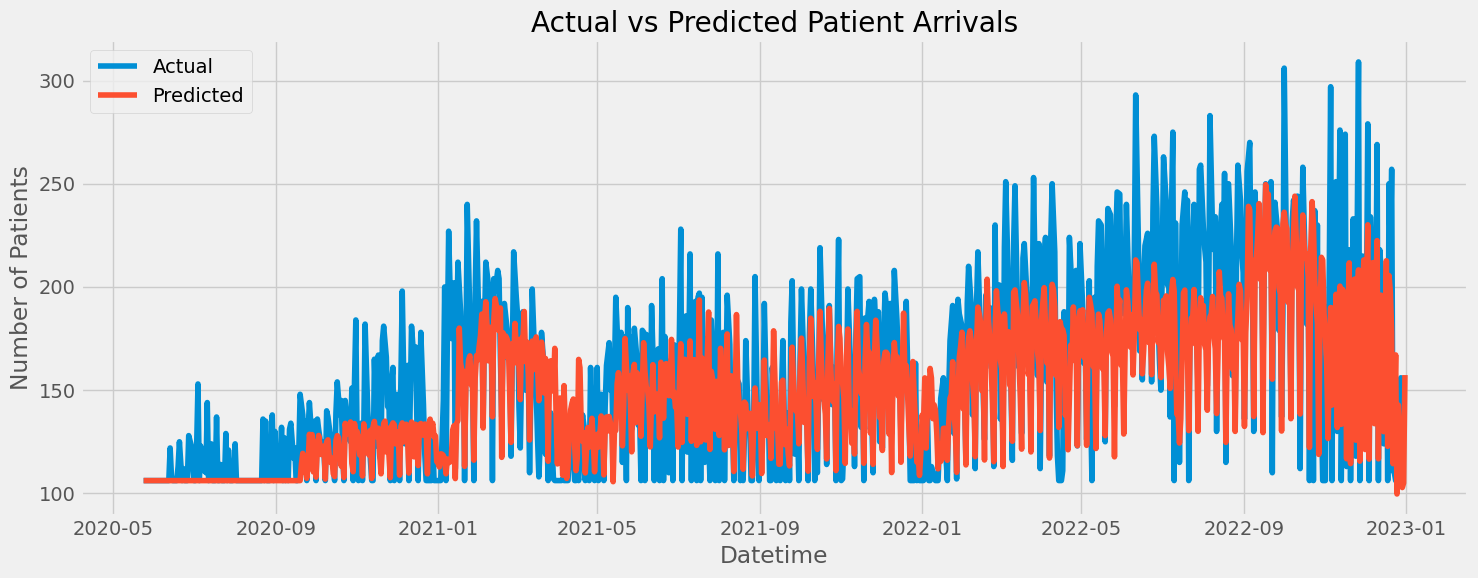

In [44]:
plt.figure(figsize=(15, 6))
plt.plot(actual_vs_pred_df.index, actual_vs_pred_df['Actual'], label='Actual')
plt.plot(actual_vs_pred_df.index, actual_vs_pred_df['Predicted'], label='Predicted')

plt.xlabel('Datetime')
plt.ylabel('Number of Patients')
plt.title('Actual vs Predicted Patient Arrivals')
plt.legend()

plt.tight_layout()
plt.show()

The predictions start of as bad, but it has started to follow the pattern around the year of 2021, and has been performing quite well as the time goes on. Now that we have been able to test our model, it is now time to generate forecasts for the future.

## Preparing to Predict the Future

The historical analysis above is unchanged and remains the documented XGBoost
experiment: data cleaning, STL decomposition, winsorization, feature engineering,
lag construction, cross-validation and feature importance all stay exactly as
they were.

What changes now is **which model produces the production forecast**. A
walk-forward backtest over 14 historical forecast origins (see `backtest/` and
`backtest/redesign_tests/`) compared the recursive XGBoost pipeline against
direct multi-horizon XGBoost, Theta, ETS, Holt, and simple baselines. Over a
180-day horizon:

| Method | MAPE |
|---|---|
| Theta (period 7) | **17.98%** |
| Weekday mean (8 weeks) | 18.27% |
| Seasonal naive (7 days) | 19.98% |
| XGBoost direct (multi-horizon) | 21.18% |
| XGBoost recursive | 22.68% |
| Last value | 24.41% |

The recursive XGBoost forecaster was the **second-worst competent method**, and
was beaten significantly by Theta (Wilcoxon p = 0.013). With 958 observations,
16 features dominated by the 7-day lag, and strong weekly seasonality, a
three-parameter Theta model matched or beat a 900-tree ensemble at every horizon.

**Production forecasting is therefore Theta(period=7).** The XGBoost pipeline is
retained above as the machine-learning analysis and is unchanged.

The XGBoost model is still retrained on the full history here, because the
feature-importance analysis further down depends on it. It is no longer the
source of the production forecast.

In [45]:
# Retrain on all data
df = create_features(df)

FEATURES = ['day_of_week', 'month', 'day_of_year', 'rolling_sum', 'rolling_mean', 
                'rolling_median', 'rolling_std', 'rolling_quantile_25', 'rolling_quantile_75', 
                'lag_7_days', 'lag_14_days', 'lag_21_days', 'lag_28_days', 'lag_30_days',
                'lag_60_days', 'lag_180_days']


TARGET = 'Patients'

X_all = df[FEATURES]
y_all = df[TARGET]
    

reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=900, 
                       early_stopping_rounds=50, 
                       tree_method='hist',
                       objective='reg:squarederror', 
                       max_depth=3, 
                       min_child_weight=3, 
                       gamma=0, 
                       learning_rate=0.01, 
                       colsample_bytree=0.9, 
                       subsample=0.7,
                       reg_lambda=0)
    
reg.fit(X_all, y_all, eval_set=[(X_all, y_all)],
       verbose=100)

[0]	validation_0-rmse:163.01636
[100]	validation_0-rmse:63.52663
[200]	validation_0-rmse:30.68425
[300]	validation_0-rmse:21.89828
[400]	validation_0-rmse:19.58207
[500]	validation_0-rmse:18.55596
[600]	validation_0-rmse:17.76836
[700]	validation_0-rmse:17.11869
[800]	validation_0-rmse:16.52630
[899]	validation_0-rmse:15.98544


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=3, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=900, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [46]:
df.index.max()

Timestamp('2022-12-31 00:00:00')

The horizon is **90 days**, starting the day after the last observation.

180 days was reduced to 90 on the basis of the backtest. The best method
(Theta, period 7) first exceeds a 20% MAPE at roughly day 141, and the 180-day
backtest showed that **no method was reliable across the full 180 days**. Ninety
days sits comfortably inside the region where Theta holds near 17% MAPE, which
is the range the evidence supports using.

In [47]:
# Production forecast: Theta(period=7) over a 90-day horizon.
#
# Theta is a classical decomposition forecaster: it separates the series into a
# linear trend and a seasonal component, fits each by damped least squares, and
# combines them analytically. It produces the whole multi-step path in a single
# call, so there is no recursion and no feedback of predictions into the feature
# construction. period=7 matches the weekly outpatient cycle established by the
# STL decomposition in cell 42.
#
# It is fitted on the observed history only. No future values are used.

from statsmodels.tsa.forecasting.theta import ThetaModel

FORECAST_DAYS = 90
THETA_PERIOD = 7

# The horizon begins the day AFTER the last observation. Starting it on
# 2022-12-31 would repeat a date that is already in the history.
future = pd.date_range(start=df.index.max() + pd.Timedelta('1 day'),
                       periods=FORECAST_DAYS, freq='D')

theta_model = ThetaModel(df['Patients'].astype(float), period=THETA_PERIOD).fit()
_theta_values = np.asarray(theta_model.forecast(FORECAST_DAYS)).ravel()

assert len(_theta_values) >= FORECAST_DAYS, \
    f'Theta returned {len(_theta_values)} values, expected >= {FORECAST_DAYS}'

forecast = pd.DataFrame({'pred': _theta_values[:FORECAST_DAYS]}, index=future)
forecast.index.name = 'Date'

future

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10', '2023-01-11', '2023-01-12',
               '2023-01-13', '2023-01-14', '2023-01-15', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24',
               '2023-01-25', '2023-01-26', '2023-01-27', '2023-01-28',
               '2023-01-29', '2023-01-30', '2023-01-31', '2023-02-01',
               '2023-02-02', '2023-02-03', '2023-02-04', '2023-02-05',
               '2023-02-06', '2023-02-07', '2023-02-08', '2023-02-09',
               '2023-02-10', '2023-02-11', '2023-02-12', '2023-02-13',
               '2023-02-14', '2023-02-15', '2023-02-16', '2023-02-17',
               '2023-02-18', '2023-02-19', '2023-02-20', '2023-02-21',
               '2023-02-22', '2023-02-23', '2023-02-24', '2023-02-25',
      

In [48]:
def recursive_forecast(reg, history, horizon, features, target='Patients'):
    """
    Multi-step forecast, generated one day ahead at a time.

    For each date in `horizon`:
      1. append the date to the history frame with a NaN target placeholder,
      2. rebuild the lag and rolling features from that frame,
      3. predict that single row,
      4. write the prediction back into the history as a pseudo-observation, so
         the next step sees it exactly as it would see a real observation.

    Because the rolling window is shifted by one day in `create_features`, step 4
    never leaks the value being predicted: the features for date t are built
    from dates strictly earlier than t.

    Returns a DataFrame indexed by the horizon dates, holding the feature values
    actually used for each prediction, plus the `pred` column.
    """
    # Start from the real observations only
    work = history[[target]].copy()
    work = work[work[target].notna()]
    
    records = []
    
    for step, date in enumerate(horizon, start=1):
        # 1. placeholder row for the date being predicted
        work = pd.concat([work, pd.DataFrame({target: [np.nan]}, index=[date])])
        
        # 2. rebuild features over history + everything predicted so far
        featured = add_lags(create_features(work))
        
        row = featured.loc[[date], features]
        if row.isna().any(axis=None):
            missing = row.columns[row.isna().any()].tolist()
            raise ValueError(f'step {step} ({date.date()}): missing features {missing}')
        
        # 3. predict this single step
        yhat = float(reg.predict(row)[0])
        
        # 4. feed the prediction back as a pseudo-observation
        work.loc[date, target] = yhat
        
        record = featured.loc[date].to_dict()
        record['pred'] = yhat
        record['step'] = step
        records.append((date, record))
    
    forecast = pd.DataFrame([r for _, r in records])
    forecast.index = pd.DatetimeIndex([d for d, _ in records])
    forecast.index.name = 'Date'
    return forecast

In [49]:
# Preview the start of the horizon that will be forecast
future[:5]

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05'],
              dtype='datetime64[ns]', name='Date', freq='D')

In [50]:
# Preview the end of the horizon
future[-5:]

DatetimeIndex(['2023-03-27', '2023-03-28', '2023-03-29', '2023-03-30',
               '2023-03-31'],
              dtype='datetime64[ns]', name='Date', freq='D')

## Feature Importance

With feature importance, we are able to know which features were proven to be the most effective for improving the model performance of the XGBoost model.

In [51]:
feature_importance = pd.DataFrame(data=reg.feature_importances_, index=reg.feature_names_in_, columns=['importance'])
feature_importance

,importance
day_of_week,0.026307
month,0.018096
day_of_year,0.030083
rolling_sum,0.080493
rolling_mean,0.062111
rolling_median,0.040006
rolling_std,0.029903
rolling_quantile_25,0.039559
rolling_quantile_75,0.036363
lag_7_days,0.382987


<Axes: title={'center': 'Feature Importance'}>

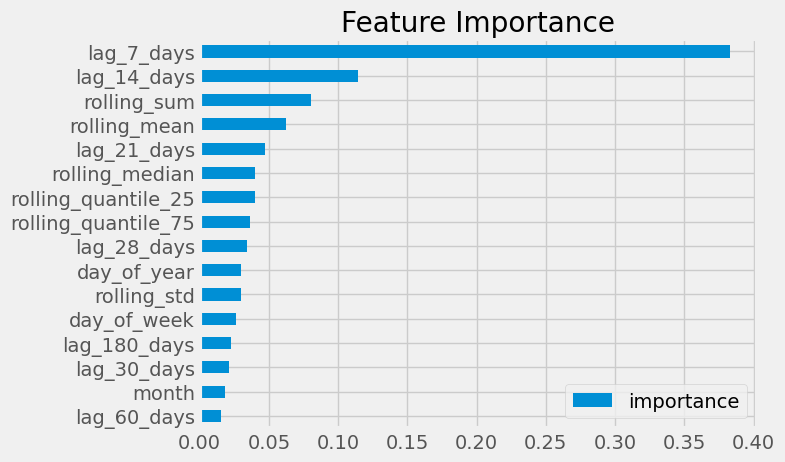

In [52]:
feature_importance.sort_values('importance').plot(kind='barh', title='Feature Importance')

It seems like the 7-day lag feature has proven to be the most effective for our forecasting model. This just proves that lags are a very essential feature for time series forecasting.

## Produce the Production Forecast

The fitted Theta model is now applied to produce the 90-day forecast that
this project ships.

## Production Forecasting with Theta(period=7)

The production forecast is generated by **Theta with a seasonal period of 7**.

`ThetaModel` decomposes the observed series into a linear trend and a
seasonal component, fits both by damped least squares, and recombines them
analytically. Because it returns the entire multi-step path in one call, there
is no recursive loop and no error accumulation, which is exactly the weakness
that the backtest exposed in the previous XGBoost forecast.

The model is fitted on `df['Patients']` — the observed history up to and
including 2022-12-31 — and nothing else. The forecast dates are constructed
separately, so no future value can reach the fit.

> **Note on the code retained below.** `recursive_forecast()` (cell 89) is the
> recursive XGBoost multi-step implementation. It is kept unchanged because it
> documents the fix applied to the earlier forecasting bug and it remains the
> method evaluated in the backtest. It is **not** used to produce the production
> forecast below.

In [53]:
# The production forecast, produced by Theta(period=7)
forecast.head()

,pred
Date,
2023-01-01,127.373190
2023-01-02,133.892284
2023-01-03,121.308166
2023-01-04,125.392199
2023-01-05,95.870041


In [54]:
# --- Acceptance checks on the Theta(period=7) production forecast --------
n = len(forecast)

print(f'horizon length            : {n} days')
print(f'horizon window           : {forecast.index.min().date()} '
      f'-> {forecast.index.max().date()}')
print(f'contiguous daily dates    : '
      f'{forecast.index.equals(pd.DatetimeIndex(future))}')
print(f'duplicated dates          : {int(forecast.index.duplicated().sum())}')
print(f'NaNs in pred              : {int(forecast["pred"].isna().sum())}')
print(f'negative predictions      : {int((forecast["pred"] < 0).sum())}')
print(f'prediction range          : {forecast["pred"].min():.2f} .. '
      f'{forecast["pred"].max():.2f}')
print(f'prediction mean / std     : {forecast["pred"].mean():.2f} / '
      f'{forecast["pred"].std():.2f}')
print(f'history mean / std        : {df["Patients"].mean():.2f} / '
      f'{df["Patients"].std():.2f}')

# exactly 90 dates
assert n == FORECAST_DAYS, f'expected {FORECAST_DAYS} days, got {n}'

# continuous daily dates
expected_index = pd.date_range(start=df.index.max() + pd.Timedelta('1 day'),
                               periods=FORECAST_DAYS, freq='D')
assert forecast.index.equals(pd.DatetimeIndex(expected_index)), \
    'forecast dates are not the expected continuous daily range'
diffs = np.diff(forecast.index.values).astype('timedelta64[D]').astype(int)
assert (diffs == 1).all(), f'non-contiguous dates found: {set(diffs)}'

# no duplicates
assert forecast.index.is_unique, 'duplicate dates in the forecast'

# no NaNs
assert not forecast['pred'].isna().any(), 'NaN values in the forecast'

# no negatives
assert (forecast['pred'] > 0).all(), 'negative patient counts in the forecast'

# sanity: the forecast should not be a flat constant, and should sit in a
# plausible range relative to the observed history
assert forecast['pred'].std() > 0, 'forecast is constant'
assert 0.5 * df['Patients'].mean() < forecast['pred'].mean() < 1.5 * df['Patients'].mean(), \
    'forecast mean is implausible relative to history'

print('\nAll checks passed.')

horizon length            : 90 days
horizon window           : 2023-01-01 -> 2023-03-31
contiguous daily dates    : True
duplicated dates          : 0
NaNs in pred              : 0
negative predictions      : 0
prediction range          : 95.87 .. 153.47
prediction mean / std     : 127.90 / 15.14
history mean / std        : 158.60 / 45.86

All checks passed.


## Verifying the Forecast

These are assertions, not commentary. If the Theta forecast ever produces a
horizon of the wrong length, missing or duplicated dates, `NaN` values, or
negative patient counts, the run fails here instead of quietly emitting a
plausible-looking chart.

In [55]:
forecast.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90 entries, 2023-01-01 to 2023-03-31
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pred    90 non-null     float64
dtypes: float64(1)
memory usage: 1.4 KB


In [56]:
# Production forecast: 90 days of predicted patient arrivals
fig = go.Figure()

fig.add_trace(go.Scatter(x=forecast.index, y=forecast['pred'],
                         name='Predicted Patient Arrivals (Theta, period 7)',
                         line=dict(color='blue', width=2),
                         hovertemplate='<b>Date</b>: %{x|%m-%d-%Y}<br>' +
                                       '<b>Patients</b>: %{y}<br>' +
                                       '<b>Day of Week</b>: %{x| %A}<extra></extra>'))

# recent history, for context
recent = df['Patients'].iloc[-60:]
fig.add_trace(go.Scatter(x=recent.index, y=recent,
                         name='Recent history (last 60 days)',
                         line=dict(color='#999999', width=1.5)))

fig.update_layout(
    title='Patient Arrival Forecast - Theta(period=7), 90-day horizon',
    xaxis=dict(
        rangeslider=dict(visible=True),
        type='date'
    ),
    yaxis_title='Predicted Patient Arrivals',
    template='plotly_white'
)

fig.update_xaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey')
fig.update_yaxes(showgrid=True, gridwidth=1, gridcolor='lightgrey')

fig.show()

The production forecast is now generated: 90 days of predicted outpatient
patient arrivals from a Theta(period=7) model fitted on the observed history.

## Save the Model

Two artifacts are relevant. The XGBoost model is saved because it remains the
documented machine-learning analysis. The Theta model is the production
forecaster, so it is saved as well.

Now we can save this model so that it can be deployed into production.

In [57]:
# Save the XGBoost analysis model (unchanged behaviour)
reg.save_model('forecast-models/xgboost_model_2.json')

# Save the production Theta(period=7) model
import pickle

with open('forecast-models/theta_period7.pkl', 'wb') as f:
    pickle.dump(theta_model, f)

print('saved forecast-models/xgboost_model_2.json (analysis model)')
print('saved forecast-models/theta_period7.pkl   (production model)')

saved forecast-models/xgboost_model_2.json (analysis model)
saved forecast-models/theta_period7.pkl   (production model)
